In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Load Dataset & Exploratory Data Analysis (EDA)

# Exploratory Data Analysis (EDA) helps us understand the dataset before building machine learning models. 
# It provides insights into the dataset's structure, summary statistics, missing values, duplicate records, 
# target class distribution, and relationships between features.

In [2]:
# Load dataset
df = pd.read_csv("heart.csv")

In [3]:
# Display first 5 rows
print("First 5 Rows:")
display(df.head())

First 5 Rows:


,age,sex,chest_pain_type,resting_bp,cholestoral,fasting_blood_sugar,restecg,max_hr,exang,oldpeak,slope,num_major_vessels,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# Dataset shape
print("Dataset Shape:", df.shape)


Dataset Shape: (303, 14)


In [5]:
# Dataset information
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  303 non-null    int64  
 1   sex                  303 non-null    int64  
 2   chest_pain_type      303 non-null    int64  
 3   resting_bp           303 non-null    int64  
 4   cholestoral          303 non-null    int64  
 5   fasting_blood_sugar  303 non-null    int64  
 6   restecg              303 non-null    int64  
 7   max_hr               303 non-null    int64  
 8   exang                303 non-null    int64  
 9   oldpeak              303 non-null    float64
 10  slope                303 non-null    int64  
 11  num_major_vessels    303 non-null    int64  
 12  thal                 303 non-null    int64  
 13  target               303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
# Statistical summary
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,age,sex,chest_pain_type,resting_bp,cholestoral,fasting_blood_sugar,restecg,max_hr,exang,oldpeak,slope,num_major_vessels,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
age                    0
sex                    0
chest_pain_type        0
resting_bp             0
cholestoral            0
fasting_blood_sugar    0
restecg                0
max_hr                 0
exang                  0
oldpeak                0
slope                  0
num_major_vessels      0
thal                   0
target                 0
dtype: int64


In [8]:
# Duplicate values
print("\nDuplicate Records:", df.duplicated().sum())



Duplicate Records: 1


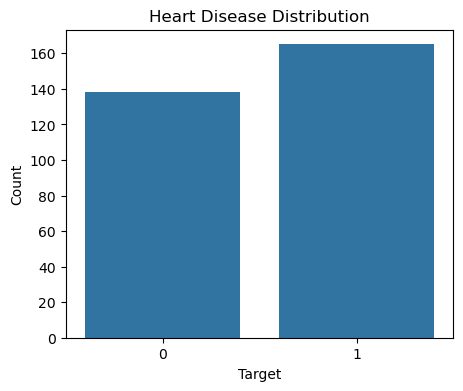

In [9]:
# Target distribution
plt.figure(figsize=(5,4))
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

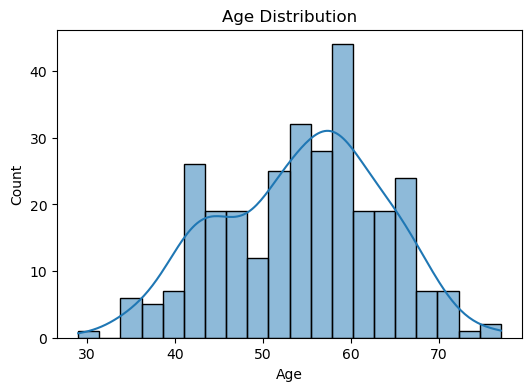

In [26]:
# Age Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

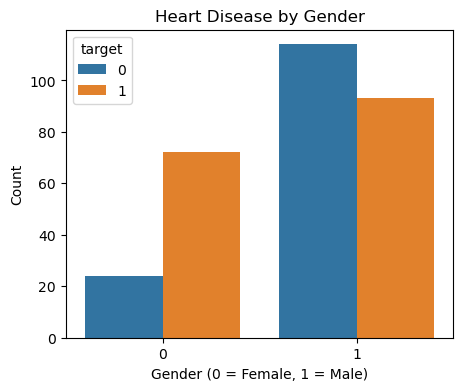

In [27]:
# Heart Disease by Gender
plt.figure(figsize=(5,4))
sns.countplot(x="sex", hue="target", data=df)

plt.title("Heart Disease by Gender")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")

plt.show()

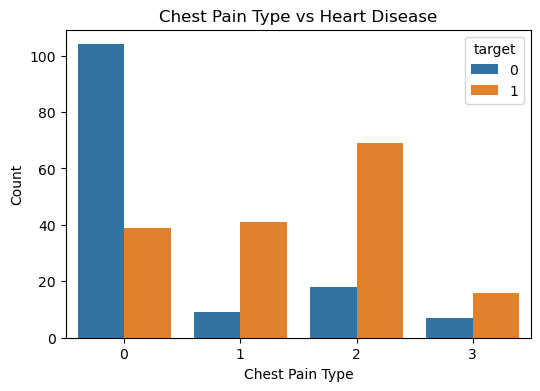

In [30]:
# Chest Pain Type Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="chest_pain_type", hue="target", data=df)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")

plt.show()

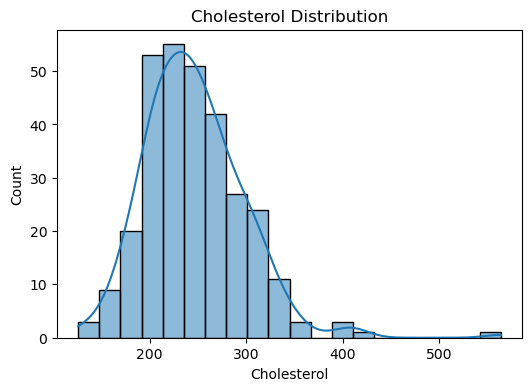

In [32]:
# Cholesterol Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["cholestoral"], bins=20, kde=True)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Count")

plt.show()

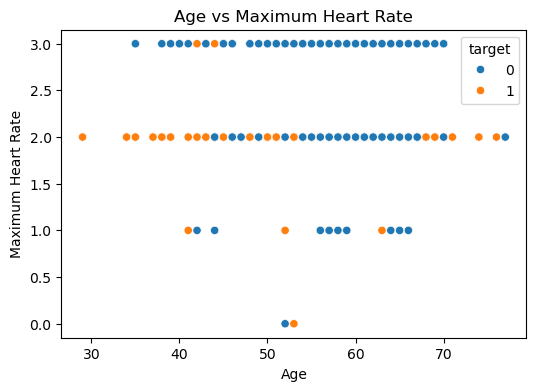

In [34]:
# Age vs Maximum Heart Rate

plt.figure(figsize=(6,4))
sns.scatterplot(
    x="age",
    y="thal",
    hue="target",
    data=df
)

plt.title("Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")

plt.show()

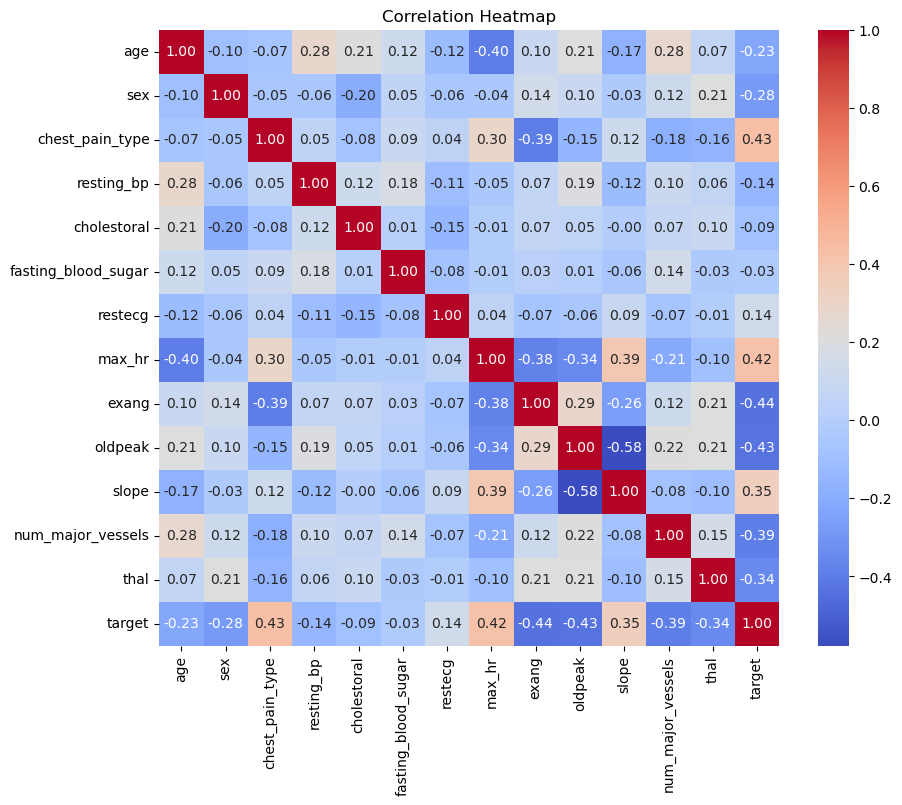

In [10]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
# Data Preprocessing

# Data preprocessing prepares the dataset for machine learning by separating the features and target variable, 
# splitting the data into training and testing sets, and standardizing the numerical features.

In [14]:
# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape: (242, 13)
Testing Data Shape : (61, 13)


In [13]:
# Logistic Regression

# Logistic Regression is a supervised machine learning algorithm used for binary classification problems. 
# It estimates the probability of a sample belonging to a particular class.


In [15]:
# Create the model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

# Predict on test data
lr_pred = lr_model.predict(X_test)

# Evaluation
print("Accuracy:", round(accuracy_score(y_test, lr_pred), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Accuracy: 0.852

Confusion Matrix:
[[25  4]
 [ 5 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [16]:
# Decision Tree

# Decision Tree is a supervised machine learning algorithm that classifies data by creating a tree-like structure 
# of decision rules. It is simple, easy to interpret, and works well for classification tasks.

In [19]:
# Create the model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predict on test data
dt_pred = dt_model.predict(X_test)

# Evaluation
print("Accuracy:", round(accuracy_score(y_test, dt_pred), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Accuracy: 0.754

Confusion Matrix:
[[25  4]
 [11 21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.86      0.77        29
           1       0.84      0.66      0.74        32

    accuracy                           0.75        61
   macro avg       0.77      0.76      0.75        61
weighted avg       0.77      0.75      0.75        61



In [20]:
# Random Forest

# Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions.
# It generally provides higher accuracy and better generalization than a single Decision Tree.

In [21]:
# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test data
rf_pred = rf_model.predict(X_test)

# Evaluation
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 0.836

Confusion Matrix:
[[24  5]
 [ 5 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [22]:
# K-Nearest Neighbors (KNN)

# K-Nearest Neighbors (KNN) is a supervised machine learning algorithm that classifies a data point based on the 
# majority class of its nearest neighbors.


In [23]:
# Create the model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Predict on test data
knn_pred = knn_model.predict(X_test)

# Evaluation
print("Accuracy:", round(accuracy_score(y_test, knn_pred), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

Accuracy: 0.902

Confusion Matrix:
[[27  2]
 [ 4 28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



In [24]:
# Model Comparison

# The performance of all classification models is compared using the evaluation metrics.

In [25]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, knn_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, knn_pred)
    ],
    "F1-Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, knn_pred)
    ]
})

comparison = comparison.round(3)

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.852,0.871,0.844,0.857
1,Decision Tree,0.754,0.840,0.656,0.737
2,Random Forest,0.836,0.844,0.844,0.844
3,KNN,0.902,0.933,0.875,0.903


In [35]:
# Feature Importance

# Feature Importance helps identify which medical attributes contribute the most to predicting heart disease.

# The Random Forest model provides an importance score for each feature based on its contribution to the prediction.

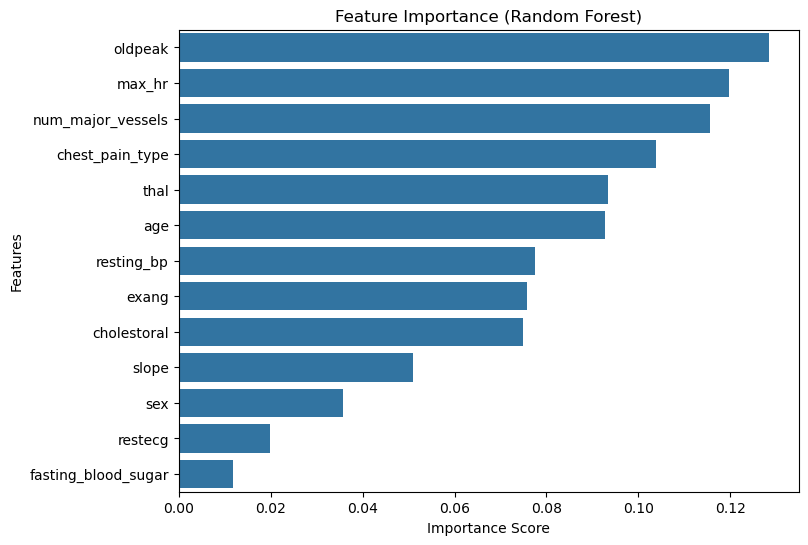

In [36]:
# Create DataFrame for feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

# Plot
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [37]:
# ROC Curve

# The Receiver Operating Characteristic (ROC) Curve evaluates the performance of classification models by comparing 
# the True Positive Rate (Sensitivity) and False Positive Rate.

# The Area Under the Curve (AUC) measures the overall performance of the model. A higher AUC value indicates better 
# classification performance.

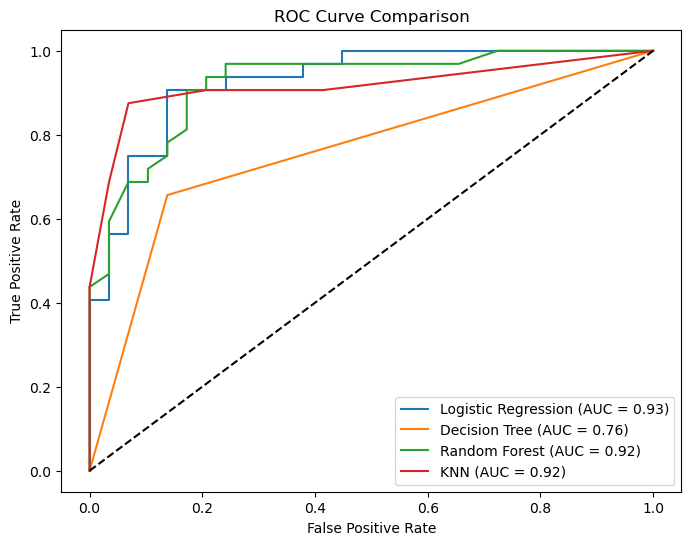

In [40]:
plt.figure(figsize=(8,6))

# Logistic Regression
lr_prob = lr_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, lr_prob)
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc(fpr, tpr):.2f})")

# Decision Tree
dt_prob = dt_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, dt_prob)
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc(fpr, tpr):.2f})")

# Random Forest
rf_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc(fpr, tpr):.2f})")

# KNN
knn_prob = knn_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, knn_prob)
plt.plot(fpr, tpr, label=f"KNN (AUC = {auc(fpr, tpr):.2f})")

# Random Guess Line
plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

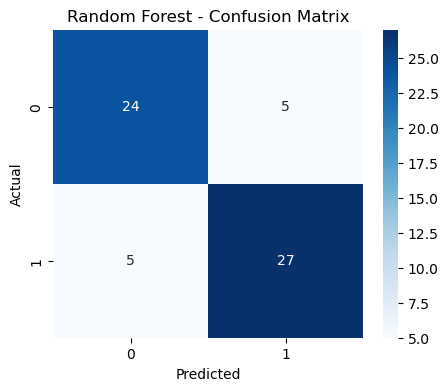

In [39]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [41]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("Best Performing Model")
print("-" * 30)
print(f"Model     : {best_model['Model']}")
print(f"Accuracy  : {best_model['Accuracy']:.3f}")
print(f"Precision : {best_model['Precision']:.3f}")
print(f"Recall    : {best_model['Recall']:.3f}")
print(f"F1-Score  : {best_model['F1-Score']:.3f}")

Best Performing Model
------------------------------
Model     : KNN
Accuracy  : 0.902
Precision : 0.933
Recall    : 0.875
F1-Score  : 0.903


In [ ]:
# Conclusion

# In this project, a Heart Disease Prediction system was developed using multiple machine learning algorithms to 
# classify whether a patient is likely to have heart disease based on various medical attributes.

# The dataset was explored through Exploratory Data Analysis (EDA), preprocessed by handling the feature and 
# target variables, splitting the dataset into training and testing sets, and standardizing the feature values 
# before model training.

# Four classification algorithms—**Logistic Regression, Decision Tree, Random Forest, and 
# K-Nearest Neighbors (KNN)**—were trained and evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

# Among all the models, **K-Nearest Neighbors (KNN)** achieved the best overall performance with an 
# **Accuracy of 90.2%**, **Precision of 93.3%**, and an **F1-Score of 90.3%**, making it the most effective model
# for this dataset. **Logistic Regression** achieved the highest **ROC-AUC score (0.93)**, indicating excellent 
# ability to distinguish between patients with and without heart disease across different classification thresholds.

# This project demonstrates how machine learning techniques can assist in the early prediction of heart disease, 
# enabling healthcare professionals to support timely diagnosis and informed clinical decision-making.